In [1]:
import pandas as pd
%load_ext autoreload
%autoreload 2

In [2]:
from mcp4cm.bpmn.dataloading.bpmn_dataset import BPMNDataset
from mcp4cm.bpmn.dataloading.dataloading import load_processed_dataset_from_csv, BPMNModelCollection
from mcp4cm.dataloading import load_dataset
from mcp4cm.base import DatasetType


In [3]:
from mcp4cm.bpmn.dataloading.dataloading import load_processed_dataset_from_csv

english_sam_deduplicated_path = 'data/bpmnmodelset/processed/sapsam/english_deduplicated_bpmn.csv'
english_bpmai_deduplicated_path = 'data/bpmnmodelset/processed/bpmai/english_deduplicated_bpmn.csv'


english_models = load_processed_dataset_from_csv('English_BPMAI', english_bpmai_deduplicated_path)

In [4]:
from mcp4cm.bpmn.analysis_and_extraction import extract_names_from_models as extract_and_analyse_names
from mcp4cm.bpmn.data_extraction import extract_names_from_models

use_types = False

if use_types:
    key = 'names_with_types'
    file_path = 'data/bpmnmodelset/processed/culled_with_typed_names.csv'
    empty_name = 'unknown type: empty name'
else:
    key = 'names'
    file_path = 'data/bpmnmodelset/processed/culled_with_names.csv'
    empty_name = 'empty name'


#extract_names_from_models(bpmn_dataset, use_types=use_types)


names
yes                                1993
no                                 1937
customer                            749
ok                                  325
client                              274
sales                               234
warehouse                           219
supplier                            212
end                                 208
rfq                                 205
rejected                            197
not ok                              189
invoice                             177
approved                            174
ssp                                 172
supervisor                          171
finance                             165
send invoice                        158
a                                   142
student                             142
b                                   141
receive invoice                     138
c                                   137
payment                             137
review purchase order             

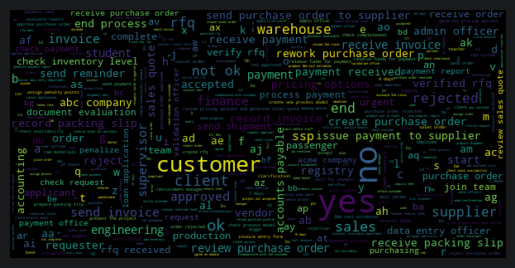

In [5]:
from mcp4cm.bpmn.analysis_and_extraction import get_all_names, create_wordcloud, get_counts
#all_names = get_all_names(english_models, key, casefold=True)
counts = get_counts(english_models, key=key, casefold=True)

create_wordcloud(counts)
counts.head(50)

In [6]:
from mcp4cm.dataloading import Dataset
from bpmn.filter_functions import filter_empty_models, filter_models_by_median_name_length, filter_models_by_min_element_count

Dataset.apply_filters(
    dataset=english_models,
    filters=[filter_empty_models,
             filter_models_by_median_name_length])

Filtered out models where every element is unnamed: 0
Filtered out models with a median name length smaller than 3: 129


Dataset(name=English_BPMAI, models=4239)

In [7]:
print(counts['empty'])
print(counts['name'])

2
2


names
yes                                1993
no                                 1937
customer                            749
ok                                  325
client                              274
sales                               234
warehouse                           219
supplier                            212
end                                 205
rfq                                 205
rejected                            197
not ok                              189
invoice                             177
approved                            173
ssp                                 172
supervisor                          171
finance                             165
send invoice                        158
student                             142
receive invoice                     138
payment                             137
review purchase order               136
engineering                         133
abc company                         122
sales quote                       

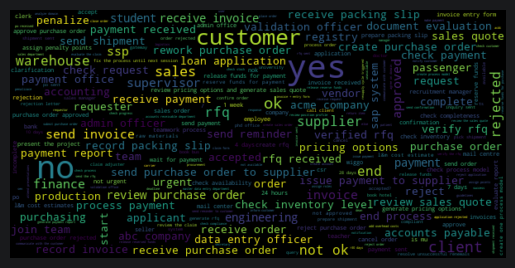

In [7]:
counts = get_counts(english_models, key=key, casefold=True)

create_wordcloud(counts)
counts.head(50)

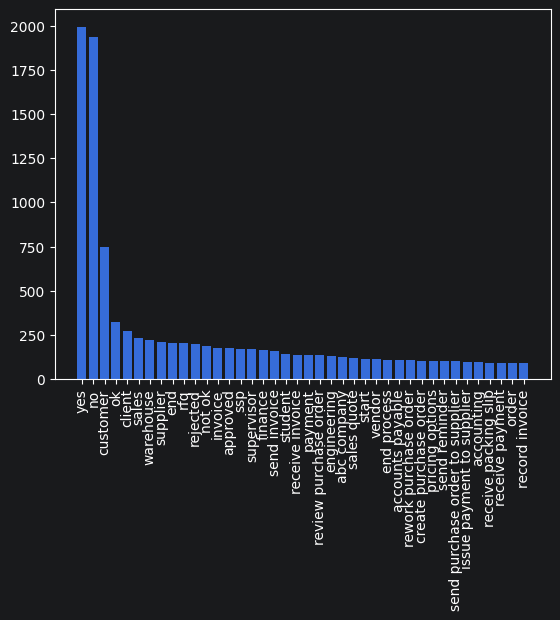

In [8]:
import matplotlib.pyplot as plt


plt.bar(counts[:40].index, counts[:40].values)
plt.xticks(rotation=90)

plt.show()

In [9]:
from mcp4cm.bpmn.analysis_and_extraction import print_all_types

print_all_types(english_models)

['BPMNDiagram', 'SequenceFlow', 'Association_Undirected', 'Pool', 'Lane', 'EndNoneEvent', 'Task', 'ITSystem', 'StartNoneEvent', 'Association_Unidirectional', 'MessageFlow', 'DataObject', 'EndTerminateEvent', 'Exclusive_Databased_Gateway', 'StartMessageEvent', 'EventbasedGateway', 'CollapsedSubprocess', 'EndMessageEvent', 'Subprocess', 'Message', 'ParallelGateway', 'IntermediateErrorEvent', 'CollapsedPool', 'TextAnnotation', 'IntermediateConditionalEvent', 'IntermediateMessageEventCatching', 'IntermediateMessageEventThrowing', 'InclusiveGateway', 'IntermediateTimerEvent', 'processparticipant', 'IntermediateSignalEventCatching', 'EndErrorEvent', 'IntermediateCompensationEventCatching', 'StartTimerEvent', 'IntermediateLinkEventThrowing', 'DataStore', 'EventSubprocess', 'StartEscalationEvent', 'IntermediateEscalationEventThrowing', 'StartErrorEvent', 'StartConditionalEvent', 'IntermediateEscalationEvent', 'Group', 'IntermediateEvent', 'Association_Bidirectional', 'IntermediateSignalEventTh

In [10]:
from mcp4cm.bpmn.analysis_and_extraction import extract_required_counts, check_minimal_model_elements

check_minimal_model_elements(english_models)
#extract_required_counts(english_models)


Total models: 4239
Valid models: 3595
Invalid models: 644


['accept request', 'accept request', 'accept request', 'accept request', 'check assigment rule', 'check assigment rule', 'check cheapest available loan', 'check credit rating', 'check security', 'check security', 'deny request', 'deny request', 'filling out loan request', 'transmitting request']
['Bakery/Fresh Bread Manufacturer', 'Barilla, Voiella, Braibanti Manufacturer', 'Catering/ International Manufacturing', 'Distributors', 'Distributors', 'Distributors', 'Distributors', 'Distributors', 'Raw Materials', 'Raw Materials', 'Raw Materials', 'Retailers', 'Retailers', 'Retailers', 'Retailers', 'Retailers']
['Cheese', 'Dairy', 'Fruit Categorization', 'Fruits', 'Milk', 'Non-perishable', 'Other', 'Perishable', 'Stored based on item policy', 'Stored based on item policy', 'Stored based on item policy', 'Stored based on item policy', 'Temperature Weight and Date Center', 'Temperature Weight and Date Center', 'Temperature Weight and Date Center', 'Temperature Weight and Date Center', 'Vegeta

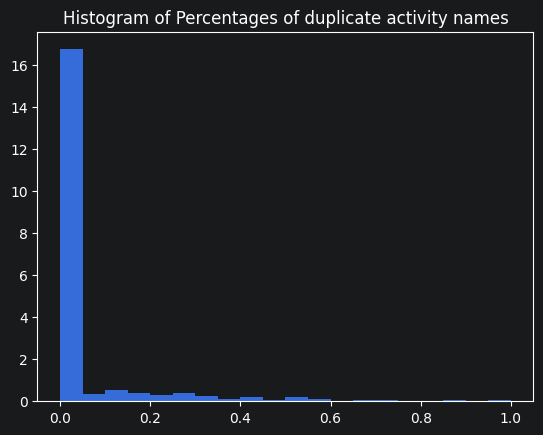

In [20]:
from mcp4cm.bpmn.analysis_and_extraction import analyse_duplicate_activity_names

analyse_duplicate_activity_names(english_models)

In [13]:
english_models.models.head()

Error removing breakpoint: Breakpoint id not found: c:\entwicklung\ba_eakg\mcp4cm\bpmn\analysis_and_extraction.py id: 192. Available ids: []

Error removing breakpoint: Breakpoint id not found: c:\entwicklung\ba_eakg\mcp4cm\bpmn\analysis_and_extraction.py id: 192. Available ids: []



KeyboardInterrupt: 

In [ ]:

from bpmn.filter_functions import filter_empty_models

print(bpmn_dataset)

filter_empty_models(bpmn_dataset, 'names', inplace=True, empty_name=empty_name)

print(bpmn_dataset)

In [ ]:
from mcp4cm.language_detection import extract_dataset_languages, get_models_by_language

extract_dataset_languages(bpmn_dataset, text_key='names', empty_name=empty_name, override=True)


In [ ]:
language_dict = get_models_by_language(bpmn_dataset)

In [ ]:
from mcp4cm.language_detection import filter_models_by_language
english_dataset = filter_models_by_language(bpmn_dataset, 'en', key='names', empty_name=empty_name)
language_dict = get_models_by_language(english_dataset)

file_path = 'data/bpmnmodelset/processed/english_models.csv'
print(len(english_dataset))
BPMNDataset.to_csv(english_dataset, file_path);


In [ ]:
file_path = 'data/bpmnmodelset/processed/english_models.csv'
loaded_dataset = load_dataset_from_csv('english_bpmn', fp=file_path)

In [ ]:
from mcp4cm.bpmn.duplicate_detection import detect_duplicates_by_hash
detect_duplicates_by_hash(loaded_dataset, inplace=True, plt_fig=True)
print(len(loaded_dataset))


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from langdetect import detect


def tfidf_near_duplicate_detector(
        dataset: BPMNDataset,
        threshold: float = 0.8,
        inplace: bool = False,
        plt_fig: bool = False,
        print_results: bool = True,
):
    def get_content(names_list: list)-> str:
        # Join with filter on empty strings
        content = " ".join(names_list)
        return content

    def get_language(content: str) -> str:
        striped_content = content.strip()
        if striped_content:
            return detect(striped_content)
        return None

    print('Joining Names to content strings')
    content_series = dataset.models['names'].apply(get_content)
    print('Creating content strings done')
    #language_series = content_series.apply(get_language)

    print('Creating Tf-Idf Matrix')
    vectorizer = TfidfVectorizer()
    tf_idf_matrix = vectorizer.fit_transform(content_series)


    print('Matrix Generation Done')
    print('Calculating Cosine Similarities')
    similarity_matrix = cosine_similarity(tf_idf_matrix, dense_output=False)
    print('Calculation of Similarity Matrix Done')
    similarity_threshold = threshold

    # Initialize groups of duplicates
    duplicate_groups = defaultdict(list)
    unique_files_indices = content_series.index # Track indices of potentially unique files
    non_unique_indices = list()
    # Efficient file comparison
    for i in range(len(unique_files_indices)):
        found_group = False

        model_id = dataset.models.at[i,'id']

        for group_id, members in list(duplicate_groups.items()):

            for member_index in members:
                if member_index != i and similarity_matrix[i][member_index] > similarity_threshold:
                    duplicate_groups[group_id].append(i)
                    found_group = True
                    non_unique_indices.append(i)
                    break
            if found_group:
                break


        # If no existing group is similar, start a new group
        if not found_group and i not in non_unique_indices:
            duplicate_groups[model_id].append(i)

    unique_files_indices = unique_files_indices.difference(non_unique_indices)

    near_duplicate_count = sum(len(indices) for indices in duplicate_groups.values() if len(indices) > 1)
    number_of_duplicate_groups = sum(1 for indices in duplicate_groups.values() if len(indices) > 1)
    unique_file_count = len(unique_files_indices) - number_of_duplicate_groups
    total_files_processed = near_duplicate_count + unique_file_count

    if print_results:
        print("\n=== Dataset Statistics ===")
        print(f"Total files processed: {total_files_processed}")
        print(f"Total unique files: {unique_file_count}")
        print(f"Total duplicate files: {near_duplicate_count}")
        print(f"Number of duplicate groups: {number_of_duplicate_groups}")

    return (near_duplicate_count/total_files_processed), number_of_duplicate_groups

In [ ]:
loaded_dataset.models.iloc[0]['names']

In [ ]:
file_path = 'data/bpmnmodelset/processed/reduced/culled_with_names.csv'
reloaded_dataset = load_dataset_from_csv("sam_reduced_models", file_path)
type(reloaded_dataset.models.iloc[0]['names'])



In [ ]:
reloaded_dataset.models.iloc[0]['names']

In [ ]:
percentage, n_groups = tfidf_near_duplicate_detector(loaded_dataset, threshold=0.8, inplace=False, plt_fig=True, print_results=True)

In [ ]:

steps = [x*0.1 for x in range(11)]
print(steps)

percent_near_duplicates = list()
number_of_duplicate_groups = list()



for step in steps:
    percentage, n_groups = tfidf_near_duplicate_detector(loaded_dataset, threshold=step, inplace=False, plt_fig=False, print_results=False)
    percent_near_duplicates.append(percentage)
    number_of_duplicate_groups.append(n_groups)





In [ ]:
from mcp4cm.util.plotting_util import plot_tf_idf_graphs

plot_tf_idf_graphs(steps, percent_near_duplicates, number_of_duplicate_groups)

In [ ]:
#english_files = language_series[language_series == 'en']

tfidf_near_duplicate_detector(loaded_dataset, threshold=0.8, inplace=False, plt_fig=False)

In [ ]:
from collections import defaultdict

hash_to_files = defaultdict(list)
output_txt_file = "hashing_results.txt"

for i in range(n_models):
    hash_to_files[hashes[i]].append(i)


duplicate_files = {h: files for h, files in hash_to_files.items() if len(files) > 1}
unique_files = {h: files[0] for h, files in hash_to_files.items() if len(files) == 1}

# Save results to a text file
with open(output_txt_file, 'w', encoding='utf-8') as txt_file:
    txt_file.write("=== Duplicate BPMN Files Detected ===\n")
    if duplicate_files:
        for file_hash, files in duplicate_files.items():
            txt_file.write(f"\nDuplicate Group (Hash: {file_hash}):\n")
            for file in files:
                txt_file.write(f"  - {file}\n")
    else:
        txt_file.write("No duplicate name files found.\n")

    txt_file.write("\n=== Unique BPMN  Files (No Duplicates) ===\n")
    if unique_files:
        for file_hash, file in unique_files.items():
            txt_file.write(f"\nUnique File (Hash: {file_hash}):\n  - {file}\n")
    else:
        txt_file.write("No unique files found.\n")

# Print execution time
print(f"Results saved to: {output_txt_file}")

In [ ]:
from mcp4cm.bpmn.dataloading.dataloading import load_processed_dataset_from_csv

file_path = 'data/bpmnmodelset/processed/bpmai/english_models.csv'

loaded_dataset = load_processed_dataset_from_csv("bpmai_english_models", file_path)

len(loaded_dataset)

models = loaded_dataset.models

In [ ]:
example_model = models.query('id == 8914774')

In [ ]:
import json
from mcp4cm.util.text_util import get_file_hash


model_text = example_model['names'].values[0]
model_json = json.dumps(model_text, sort_keys=True)
print(model_json)
print(get_file_hash(model_json))

In [ ]:
from mcp4cm.bpmn.dataloading.dataloading import load_processed_dataset_from_csv

file_path = 'data/bpmnmodelset/processed/bpmai/english_typed_models.csv'

loaded_dataset = load_processed_dataset_from_csv("bpmai_english_typed_models", file_path)

len(loaded_dataset)

models = loaded_dataset.models

In [ ]:
example_model = models.query('id == 8914774')

In [ ]:
import json
from mcp4cm.util.text_util import get_file_hash

model_text = example_model['names_with_types'].values[0]
model_json = json.dumps(model_text, sort_keys=True)
print(model_json)
print(get_file_hash(model_json))